# EDA v2 — Dataset 3: Patient Segmentation

**Versión resumida y enfocada.** Parte de los hallazgos del EDA v1 para profundizar en lo que importa:
- Los nulos intencionales y calidad de datos
- La cadena principal: Edad → Cronicidad → Facturación
- La paradoja del seguro (Medicare > Privado)
- La paradoja preventiva (preventivos gastan *más*)
- Feature engineering completo para fases siguientes

**Dataset:** 2,000 pacientes · 16 variables · EE.UU.

In [2]:
# === OPCION 1: Carga LOCAL (usar esta si corres en tu PC) ===
filepath = '3_patient_segmentation_dataset.csv'

# === OPCION 2: Montar Google Drive ===
# from google.colab import drive
# drive.mount('/content/drive')
# filepath = '/content/drive/MyDrive/RUTA_A_TU_ARCHIVO/3_patient_segmentation_dataset.csv'

# === OPCION 3: Subir archivo manualmente en Colab ===
# from google.colab import files
# uploaded = files.upload()
# filepath = '3_patient_segmentation_dataset.csv'

In [3]:
# Instalar librerias necesarias (descomentar si no las tenes instaladas)
# !pip install pandas numpy matplotlib seaborn plotly scipy scikit-learn
# pip install pandas numpy matplotlib seaborn plotly scipy scikit-learn

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11

df = pd.read_csv('3_patient_segmentation_dataset.csv', parse_dates=['Last_Visit_Date'])
print(f'Shape: {df.shape}')
print(f'Duplicados: {df.duplicated().sum()}')
print(f'\nNulos por columna:')
nulos = df.isnull().sum()
print(nulos[nulos > 0].to_string())
df.head(3)

Shape: (2000, 16)
Duplicados: 0

Nulos por columna:
Primary_Condition    495


,PatientID,Age,Gender,State,City,Height_cm,Weight_kg,BMI,Insurance_Type,Primary_Condition,Num_Chronic_Conditions,Annual_Visits,Avg_Billing_Amount,Last_Visit_Date,Days_Since_Last_Visit,Preventive_Care_Flag
0,P10000,64,Male,GA,Unknown,151,115,50.4,Private,Arthritis,3,7,2995.0,2025-07-18,186,0
1,P10001,59,Male,OH,Unknown,189,68,19.0,Medicare,Depression,1,8,1209.0,2025-12-12,39,0
2,P10002,58,Female,PA,Unknown,156,91,37.4,Private,Asthma,1,4,999.0,2025-09-16,126,0


## 1. Nulos intencionales y calidad de datos

Los 495 nulos en `Primary_Condition` no son errores — son pacientes con `Num_Chronic_Conditions = 0`.  
Los imputamos como `'None'` y verificamos la consistencia.

In [7]:
# --- Verificar que los nulos coinciden exactamente con Chronic = 0 ---
nulos_condition = df['Primary_Condition'].isnull()
chronic_zero = df['Num_Chronic_Conditions'] == 0

print('=== ANÁLISIS DE NULOS EN Primary_Condition ===')
print(f'  Nulos en Primary_Condition:              {nulos_condition.sum()}')
print(f'  Pacientes con 0 condiciones crónicas:    {chronic_zero.sum()}')
print(f'  Coincidencia exacta:                     {(nulos_condition == chronic_zero).all()}')
print(f'  Conclusión: Los nulos son INTENCIONALES — pacientes sanos')

# Imputar
df['Primary_Condition'] = df['Primary_Condition'].fillna('None')
print(f'\nPrimary_Condition imputada → nulos restantes: {df["Primary_Condition"].isnull().sum()}')

# --- Unknowns en City ---
print(f'\n"Unknown" en City: {(df["City"] == "Unknown").sum()} ({(df["City"] == "Unknown").mean():.1%})')
print(f'"Unknown" en State: {(df["State"] == "Unknown").sum()}')

# --- Balance de género ---
print(f'\nBalance de género: {dict(df["Gender"].value_counts())}')
print('  → Perfectamente balanceado: posible dato sintético o controlado')

=== ANÁLISIS DE NULOS EN Primary_Condition ===
  Nulos en Primary_Condition:              0
  Pacientes con 0 condiciones crónicas:    495
  Coincidencia exacta:                     False
  Conclusión: Los nulos son INTENCIONALES — pacientes sanos

Primary_Condition imputada → nulos restantes: 0

"Unknown" en City: 1012 (50.6%)
"Unknown" en State: 0

Balance de género: {'Female': np.int64(1001), 'Male': np.int64(999)}
  → Perfectamente balanceado: posible dato sintético o controlado


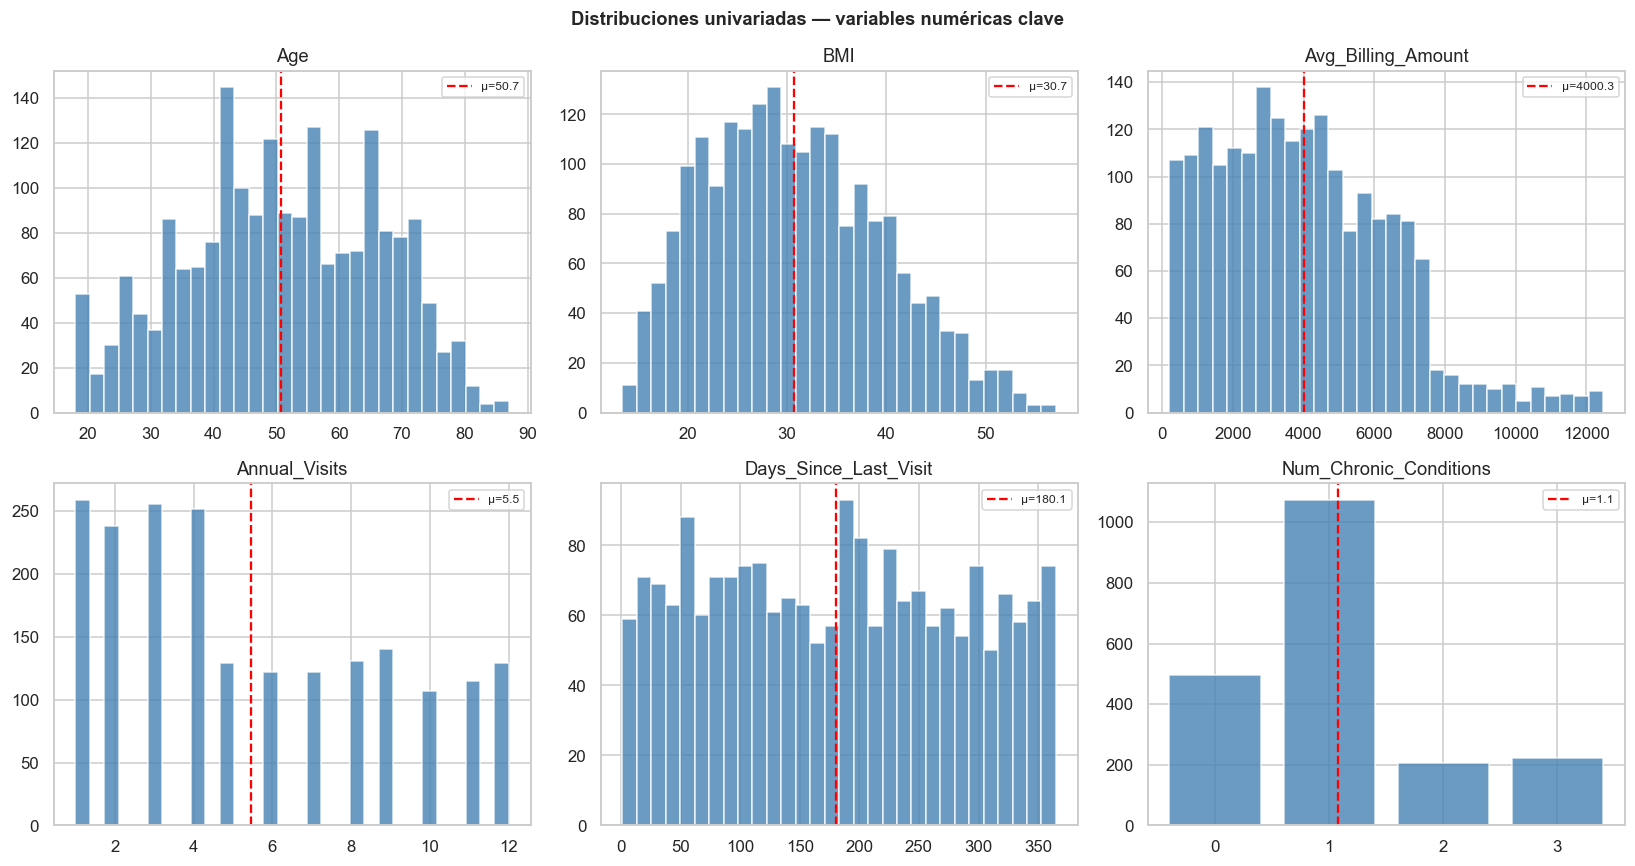

In [8]:
# --- Vista rápida de distribuciones numéricas ---
num_cols = ['Age', 'BMI', 'Avg_Billing_Amount', 'Annual_Visits', 
            'Days_Since_Last_Visit', 'Num_Chronic_Conditions']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    if df[col].nunique() <= 4:
        vc = df[col].value_counts().sort_index()
        ax.bar(vc.index.astype(str), vc.values, color='steelblue', alpha=0.8)
    else:
        ax.hist(df[col], bins=30, color='steelblue', alpha=0.8, edgecolor='white')
    
    mean_val = df[col].mean()
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'μ={mean_val:.1f}')
    ax.set_title(col)
    ax.legend(fontsize=8)

plt.suptitle('Distribuciones univariadas — variables numéricas clave', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 2. La cadena principal: Edad → Cronicidad → Facturación

La relación más fuerte del dataset. Cada eslabón tiene una correlación significativa.  
`Age → Num_Chronic_Conditions (r=0.80)` → `Avg_Billing_Amount (r=0.43)`

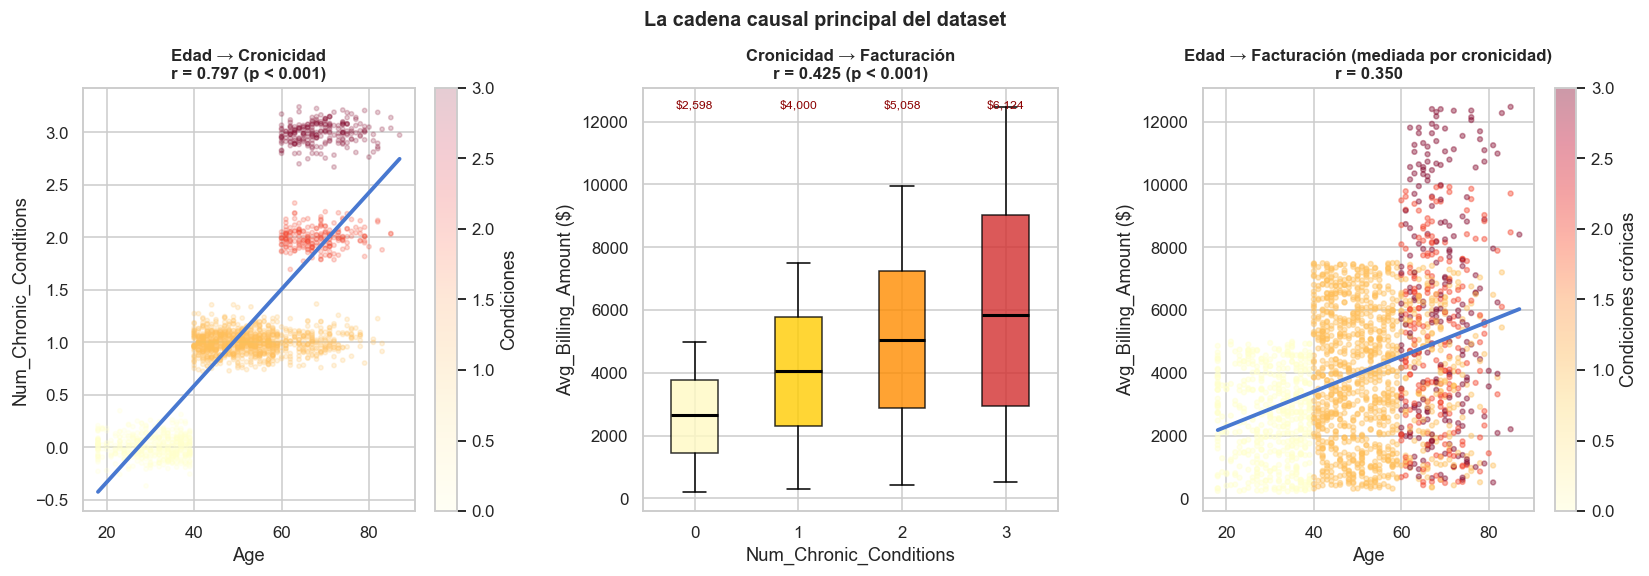

=== RESUMEN DE LA CADENA ===
  0 condición(es):  495 pacientes | Edad media: 30.4 | Facturación media: $2,598
  1 condición(es): 1074 pacientes | Edad media: 52.8 | Facturación media: $4,000
  2 condición(es):  207 pacientes | Edad media: 68.2 | Facturación media: $5,058
  3 condición(es):  224 pacientes | Edad media: 69.1 | Facturación media: $6,124


In [10]:
# --- Visualizar la cadena ---
fig = plt.figure(figsize=(18, 5))
gs = fig.add_gridspec(1, 3, hspace=0.4, wspace=0.35)

# 1. Edad → Cronicidad
ax1 = fig.add_subplot(gs[0])
r1, p1 = stats.pearsonr(df['Age'], df['Num_Chronic_Conditions'])
sc1 = ax1.scatter(df['Age'], df['Num_Chronic_Conditions'] + np.random.normal(0, 0.1, len(df)),
                  alpha=0.2, s=8, c=df['Num_Chronic_Conditions'], cmap='YlOrRd')
z = np.polyfit(df['Age'], df['Num_Chronic_Conditions'], 1)
p_fit = np.poly1d(z)
x_line = np.linspace(df['Age'].min(), df['Age'].max(), 100)
ax1.plot(x_line, p_fit(x_line), 'b-', linewidth=2.5)
ax1.set_xlabel('Age')
ax1.set_ylabel('Num_Chronic_Conditions')
ax1.set_title(f'Edad → Cronicidad\nr = {r1:.3f} (p < 0.001)', fontsize=11, fontweight='bold')
plt.colorbar(sc1, ax=ax1, label='Condiciones')

# 2. Cronicidad → Facturación (boxplot por nivel)
ax2 = fig.add_subplot(gs[1])
chronic_billing = [df[df['Num_Chronic_Conditions'] == i]['Avg_Billing_Amount'].values 
                   for i in sorted(df['Num_Chronic_Conditions'].unique())]
bp = ax2.boxplot(chronic_billing, labels=sorted(df['Num_Chronic_Conditions'].unique()),
                 patch_artist=True, medianprops={'color': 'black', 'linewidth': 2})
colors_chron = ['#FFF9C4', '#FFCC02', '#FF8C00', '#D32F2F']
for patch, color in zip(bp['boxes'], colors_chron):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

r2, p2 = stats.pearsonr(df['Num_Chronic_Conditions'], df['Avg_Billing_Amount'])

# Medias por nivel
means = df.groupby('Num_Chronic_Conditions')['Avg_Billing_Amount'].mean()
for i, (lvl, mean) in enumerate(means.items()):
    ax2.text(i+1, ax2.get_ylim()[1] * 0.95, f'${mean:,.0f}', ha='center', fontsize=8, color='darkred')

ax2.set_xlabel('Num_Chronic_Conditions')
ax2.set_ylabel('Avg_Billing_Amount ($)')
ax2.set_title(f'Cronicidad → Facturación\nr = {r2:.3f} (p < 0.001)', fontsize=11, fontweight='bold')

# 3. Edad → Facturación (mediado por cronicidad)
ax3 = fig.add_subplot(gs[2])
r3, p3 = stats.pearsonr(df['Age'], df['Avg_Billing_Amount'])
scatter = ax3.scatter(df['Age'], df['Avg_Billing_Amount'],
                      c=df['Num_Chronic_Conditions'], cmap='YlOrRd',
                      alpha=0.4, s=10)
z3 = np.polyfit(df['Age'], df['Avg_Billing_Amount'], 1)
p_fit3 = np.poly1d(z3)
ax3.plot(x_line, p_fit3(x_line), 'b-', linewidth=2.5)
ax3.set_xlabel('Age')
ax3.set_ylabel('Avg_Billing_Amount ($)')
ax3.set_title(f'Edad → Facturación (mediada por cronicidad)\nr = {r3:.3f}', fontsize=11, fontweight='bold')
plt.colorbar(scatter, ax=ax3, label='Condiciones crónicas')

plt.suptitle('La cadena causal principal del dataset', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('=== RESUMEN DE LA CADENA ===')
for lvl in sorted(df['Num_Chronic_Conditions'].unique()):
    sub = df[df['Num_Chronic_Conditions'] == lvl]
    print(f'  {lvl} condición(es): {len(sub):4d} pacientes | '
          f'Edad media: {sub["Age"].mean():.1f} | '
          f'Facturación media: ${sub["Avg_Billing_Amount"].mean():,.0f}')

## 3. Tipo de seguro y costos — la paradoja Medicare

**H1:** Seguro privado → mayor costo.  
**Resultado:** Medicare tiene la facturación más alta. ¿Por qué? Porque cubre pacientes mayores con más cronicidad.

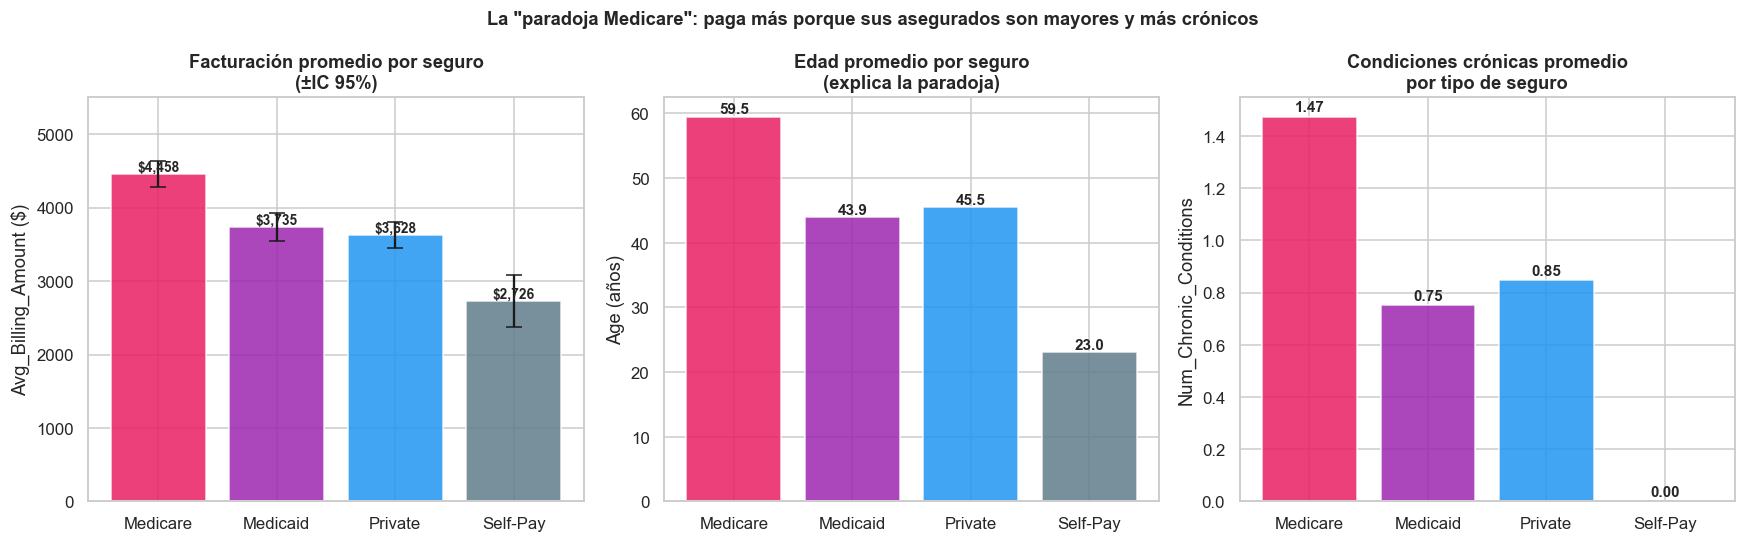


ANOVA — Facturación por tipo de seguro: F=23.10, p=0.0000
Tabla resumen:
                  N  Edad_media  Cronicidad_media  Facturacion_media
Insurance_Type                                                      
Medicare        906       59.47              1.47            4458.49
Medicaid        483       43.89              0.75            3735.13
Private         545       45.49              0.85            3627.78
Self-Pay         66       23.03              0.00            2726.32


In [11]:
# --- Paradoja Medicare: más caro porque pacientes más viejos y crónicos ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

insurance_order = ['Medicare', 'Medicaid', 'Private', 'Self-Pay']
palette = ['#E91E63', '#9C27B0', '#2196F3', '#607D8B']

# 1. Facturación por seguro
billing_by_ins = df.groupby('Insurance_Type')['Avg_Billing_Amount'].agg(['mean', 'sem']).loc[insurance_order]
axes[0].bar(insurance_order, billing_by_ins['mean'], 
            yerr=billing_by_ins['sem'] * 1.96, color=palette, alpha=0.85, capsize=5)
for i, (ins, row) in enumerate(billing_by_ins.iterrows()):
    axes[0].text(i, row['mean'] + 50, f'${row["mean"]:,.0f}', ha='center', fontsize=9, fontweight='bold')
axes[0].set_title('Facturación promedio por seguro\n(±IC 95%)', fontweight='bold')
axes[0].set_ylabel('Avg_Billing_Amount ($)')
axes[0].set_ylim(0, 5500)

# 2. Edad promedio por seguro (¿por qué Medicare es más caro?)
age_by_ins = df.groupby('Insurance_Type')['Age'].mean().loc[insurance_order]
axes[1].bar(insurance_order, age_by_ins.values, color=palette, alpha=0.85)
for i, v in enumerate(age_by_ins.values):
    axes[1].text(i, v + 0.5, f'{v:.1f}', ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('Edad promedio por seguro\n(explica la paradoja)', fontweight='bold')
axes[1].set_ylabel('Age (años)')

# 3. Cronicidad promedio por seguro
chron_by_ins = df.groupby('Insurance_Type')['Num_Chronic_Conditions'].mean().loc[insurance_order]
axes[2].bar(insurance_order, chron_by_ins.values, color=palette, alpha=0.85)
for i, v in enumerate(chron_by_ins.values):
    axes[2].text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=10, fontweight='bold')
axes[2].set_title('Condiciones crónicas promedio\npor tipo de seguro', fontweight='bold')
axes[2].set_ylabel('Num_Chronic_Conditions')

plt.suptitle('La "paradoja Medicare": paga más porque sus asegurados son mayores y más crónicos',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ANOVA para verificar si la diferencia es significativa
groups = [df[df['Insurance_Type'] == ins]['Avg_Billing_Amount'] for ins in insurance_order]
f_stat, p_anova = stats.f_oneway(*groups)
print(f'\nANOVA — Facturación por tipo de seguro: F={f_stat:.2f}, p={p_anova:.4f}')
print('Tabla resumen:')
summary = df.groupby('Insurance_Type').agg(
    N=('PatientID', 'count'),
    Edad_media=('Age', 'mean'),
    Cronicidad_media=('Num_Chronic_Conditions', 'mean'),
    Facturacion_media=('Avg_Billing_Amount', 'mean')
).loc[insurance_order].round(2)
print(summary.to_string())

## 4. Análisis de condiciones médicas

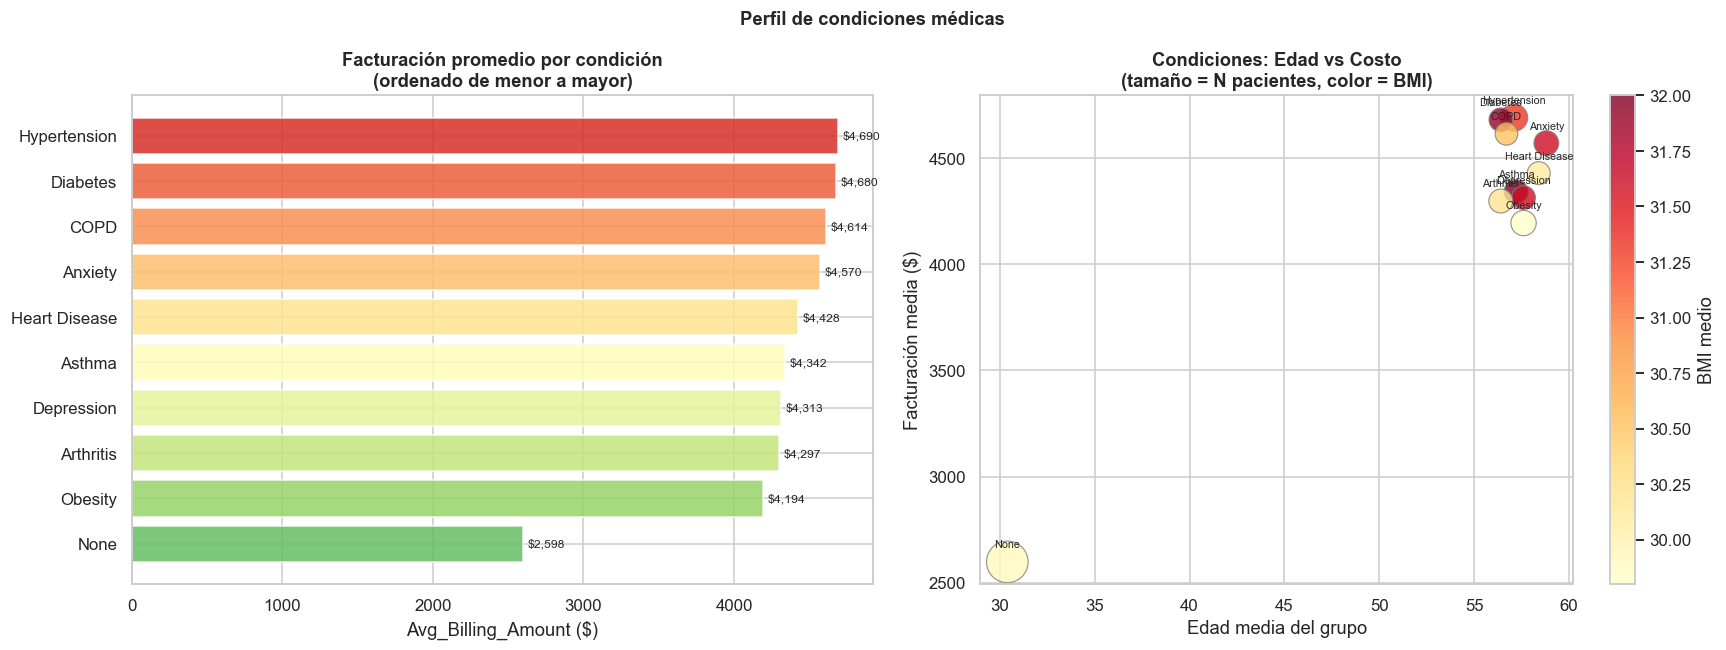


Resumen por condición:
                     N  Facturacion_media  Edad_media  BMI_medio  Visitas_media
Primary_Condition                                                              
Hypertension       210             4689.8        57.1       31.3            6.4
Diabetes           158             4679.8        56.4       31.9            6.6
COPD               146             4613.5        56.7       30.5            6.3
Anxiety            175             4569.7        58.8       31.6            6.4
Heart Disease      150             4428.3        58.4       30.1            5.9
Asthma             160             4341.6        57.2       32.0            6.9
Depression         160             4313.0        57.6       31.6            6.7
Arthritis          163             4297.2        56.4       30.2            6.0
Obesity            183             4193.5        57.6       29.8            6.7
None               495             2598.3        30.4       29.9            2.5


In [12]:
# --- Condiciones: frecuencia, costo, cronicidad ---
cond_stats = df.groupby('Primary_Condition').agg(
    N=('PatientID', 'count'),
    Facturacion_media=('Avg_Billing_Amount', 'mean'),
    Edad_media=('Age', 'mean'),
    BMI_medio=('BMI', 'mean'),
    Visitas_media=('Annual_Visits', 'mean')
).sort_values('Facturacion_media', ascending=False).round(1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Barplot facturación por condición
cond_order = cond_stats.sort_values('Facturacion_media', ascending=True).index
colors_cond = plt.cm.RdYlGn_r(np.linspace(0.2, 0.9, len(cond_order)))
axes[0].barh(cond_order, cond_stats.loc[cond_order, 'Facturacion_media'],
             color=colors_cond, alpha=0.85)
for i, cond in enumerate(cond_order):
    v = cond_stats.loc[cond, 'Facturacion_media']
    axes[0].text(v + 30, i, f'${v:,.0f}', va='center', fontsize=8)
axes[0].set_title('Facturación promedio por condición\n(ordenado de menor a mayor)', fontweight='bold')
axes[0].set_xlabel('Avg_Billing_Amount ($)')

# Bubble chart: Edad vs Costo, tamaño = N, color = BMI
sc = axes[1].scatter(
    cond_stats['Edad_media'],
    cond_stats['Facturacion_media'],
    s=cond_stats['N'] * 1.5,
    c=cond_stats['BMI_medio'],
    cmap='YlOrRd', alpha=0.8, edgecolors='gray', linewidths=0.8
)
plt.colorbar(sc, ax=axes[1], label='BMI medio')
for cond, row in cond_stats.iterrows():
    axes[1].annotate(cond, (row['Edad_media'], row['Facturacion_media']),
                     fontsize=7, ha='center', va='bottom',
                     xytext=(0, 8), textcoords='offset points')
axes[1].set_xlabel('Edad media del grupo')
axes[1].set_ylabel('Facturación media ($)')
axes[1].set_title('Condiciones: Edad vs Costo\n(tamaño = N pacientes, color = BMI)', fontweight='bold')

plt.suptitle('Perfil de condiciones médicas', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nResumen por condición:')
print(cond_stats.sort_values('Facturacion_media', ascending=False).to_string())

## 5. La paradoja preventiva (H3)

**H3:** Prevención reduce costos.  
**Resultado:** Los pacientes con `Preventive_Care_Flag=1` gastan *más*. Hipótesis: selection bias — los crónicos son los que más acceden a prevención.

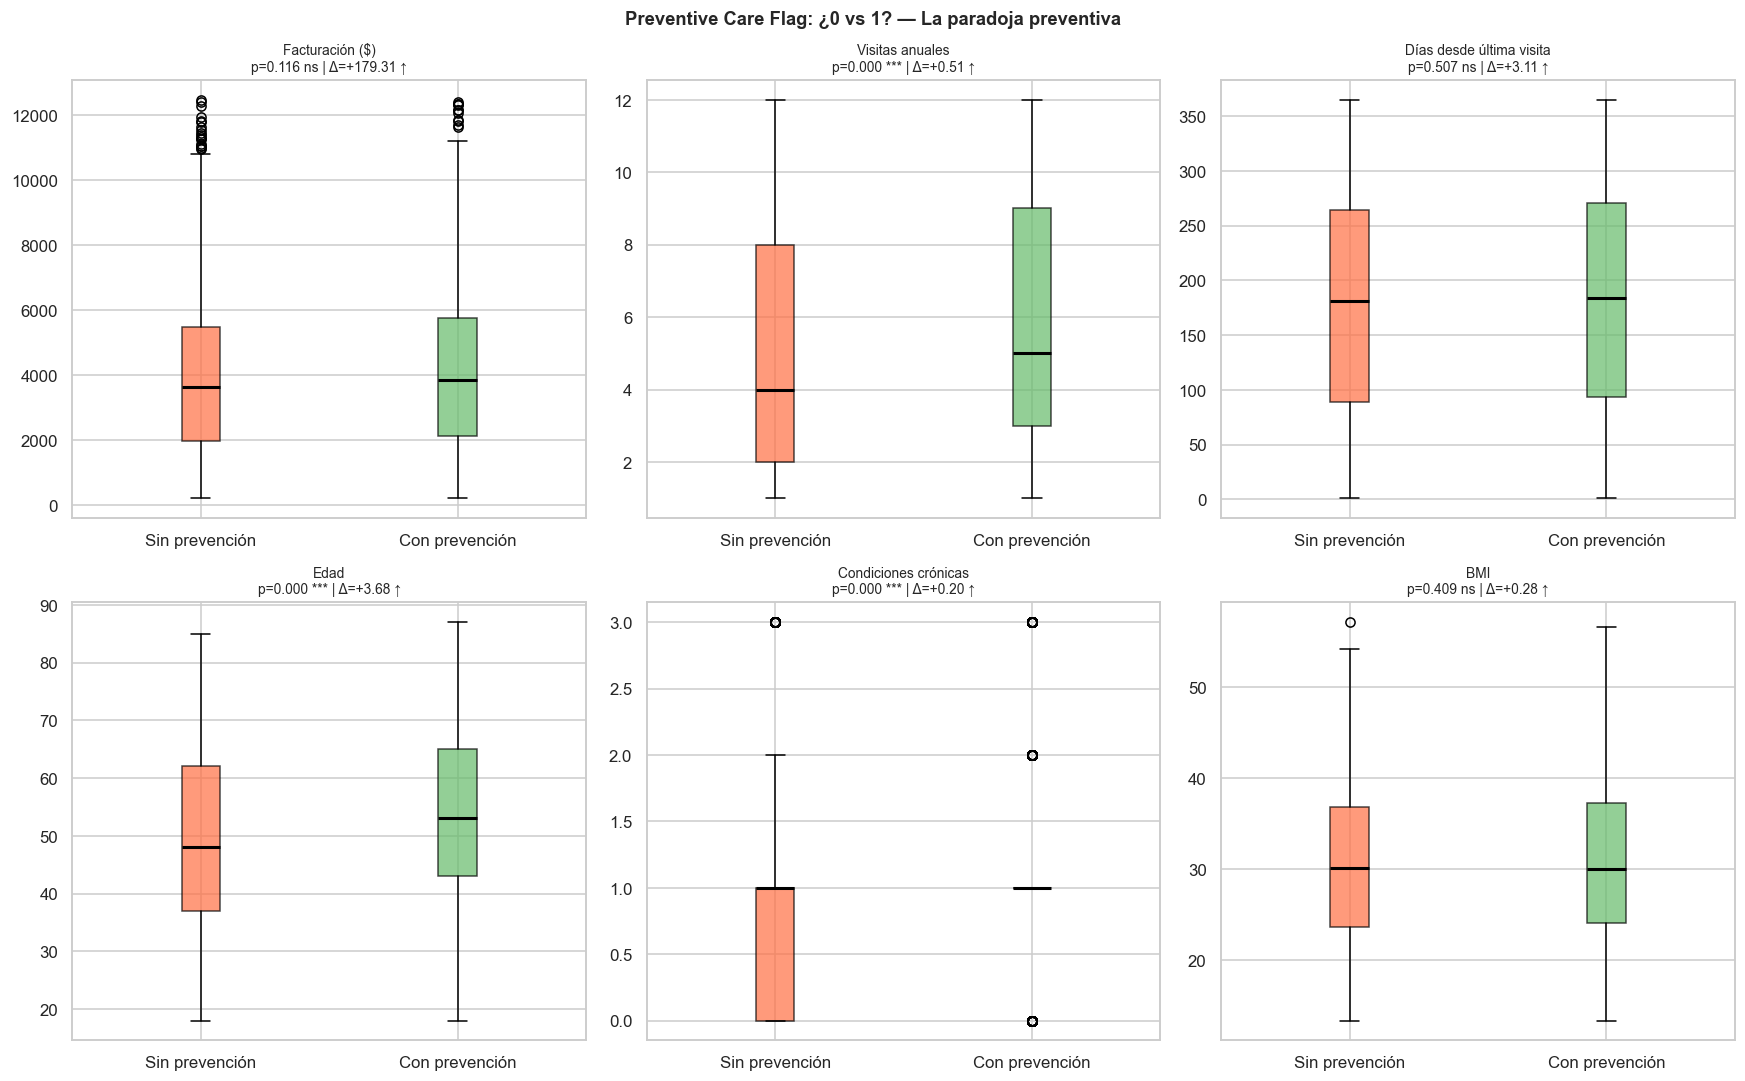

=== ¿POR QUÉ LOS PREVENTIVOS GASTAN MÁS? ===

Distribución de Num_Chronic_Conditions por Preventive_Care_Flag:
                        Sin prevención (%)  Con prevención (%)
Num_Chronic_Conditions                                        
0                                     30.0                18.6
1                                     50.6                57.3
2                                     10.2                10.6
3                                      9.2                13.5

→ Conclusión: el flag puede estar capturando el acceso al sistema (ya crónicos),
  no el comportamiento preventivo en sí. Sesgo de selección confirmado.


In [13]:
# --- Paradoja preventiva: profundidad ---
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

metrics_prev = [
    ('Avg_Billing_Amount', 'Facturación ($)'),
    ('Annual_Visits', 'Visitas anuales'),
    ('Days_Since_Last_Visit', 'Días desde última visita'),
    ('Age', 'Edad'),
    ('Num_Chronic_Conditions', 'Condiciones crónicas'),
    ('BMI', 'BMI'),
]

for ax, (metric, label) in zip(axes.flatten(), metrics_prev):
    group0 = df[df['Preventive_Care_Flag'] == 0][metric]
    group1 = df[df['Preventive_Care_Flag'] == 1][metric]
    
    _, p_val = stats.mannwhitneyu(group0, group1, alternative='two-sided')
    sig = '***' if p_val < 0.001 else ('**' if p_val < 0.01 else ('*' if p_val < 0.05 else 'ns'))
    
    bp = ax.boxplot([group0, group1], labels=['Sin prevención', 'Con prevención'],
                   patch_artist=True, medianprops={'color': 'black', 'linewidth': 2})
    bp['boxes'][0].set_facecolor('#FF7043')
    bp['boxes'][0].set_alpha(0.7)
    bp['boxes'][1].set_facecolor('#66BB6A')
    bp['boxes'][1].set_alpha(0.7)
    
    diff = group1.mean() - group0.mean()
    arrow = '↑' if diff > 0 else '↓'
    ax.set_title(f'{label}\np={p_val:.3f} {sig} | Δ={diff:+.2f} {arrow}', fontsize=9)

plt.suptitle('Preventive Care Flag: ¿0 vs 1? — La paradoja preventiva',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Explicación de la paradoja: ¿los preventivos son más crónicos?
print('=== ¿POR QUÉ LOS PREVENTIVOS GASTAN MÁS? ===')
print('\nDistribución de Num_Chronic_Conditions por Preventive_Care_Flag:')
crosstab = pd.crosstab(df['Num_Chronic_Conditions'], df['Preventive_Care_Flag'],
                        normalize='columns') * 100
crosstab.columns = ['Sin prevención (%)', 'Con prevención (%)']
print(crosstab.round(1).to_string())

print('\n→ Conclusión: el flag puede estar capturando el acceso al sistema (ya crónicos),')
print('  no el comportamiento preventivo en sí. Sesgo de selección confirmado.')

## 6. Análisis demográfico: género y geografía

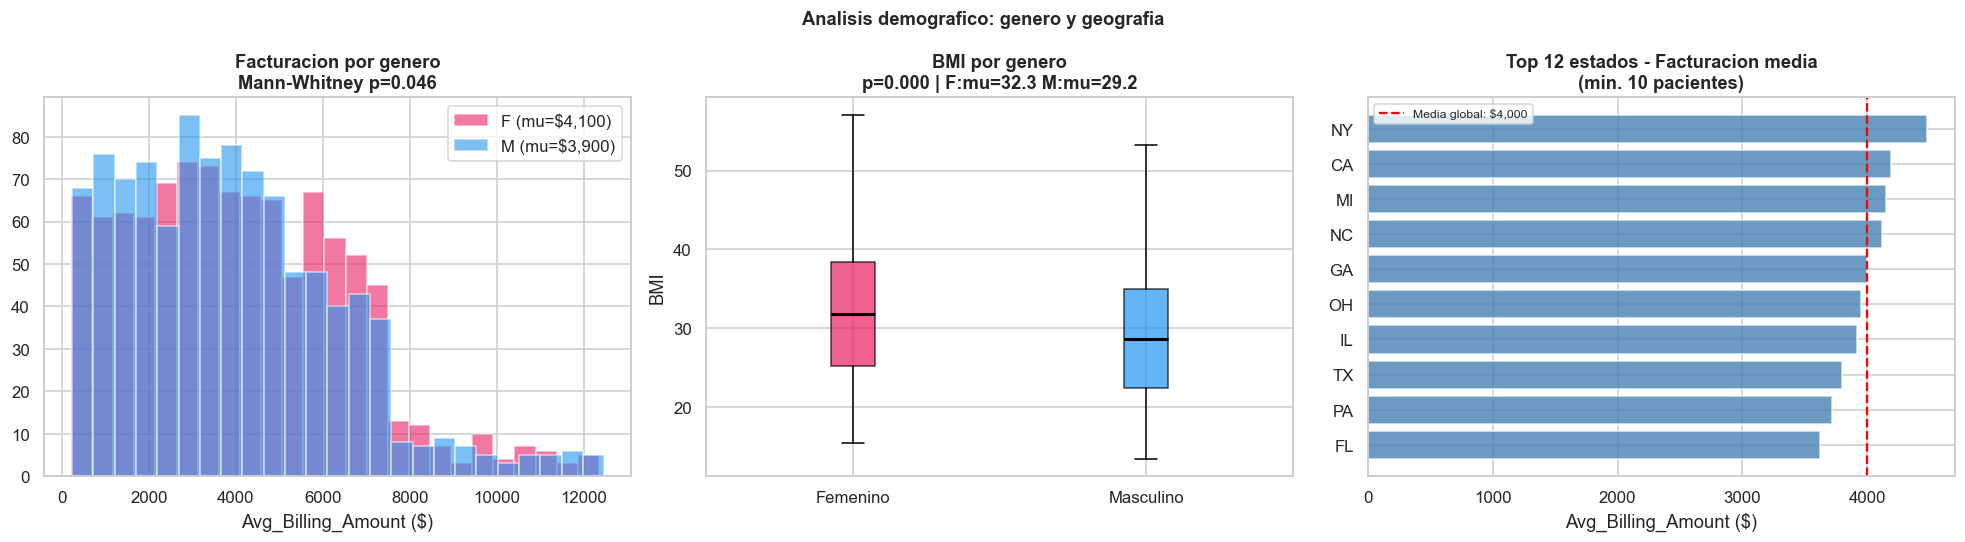

In [15]:
# --- Genero y top estados ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Facturacion por genero
for gender, color, label in [('Female', '#E91E63', 'F'), ('Male', '#2196F3', 'M')]:
    data = df[df['Gender'] == gender]['Avg_Billing_Amount']
    axes[0].hist(data, bins=25, alpha=0.6, color=color,
                 label=f'{label} (mu=${data.mean():,.0f})', edgecolor='white')
_, p_gender = stats.mannwhitneyu(
    df[df['Gender'] == 'Female']['Avg_Billing_Amount'],
    df[df['Gender'] == 'Male']['Avg_Billing_Amount']
)
axes[0].set_title('Facturacion por genero\nMann-Whitney p=' + f'{p_gender:.3f}', fontweight='bold')
axes[0].set_xlabel('Avg_Billing_Amount ($)')
axes[0].legend()

# 2. BMI por genero
bmi_f = df[df['Gender'] == 'Female']['BMI']
bmi_m = df[df['Gender'] == 'Male']['BMI']
_, p_bmi = stats.mannwhitneyu(bmi_f, bmi_m)
axes[1].boxplot([bmi_f, bmi_m], labels=['Femenino', 'Masculino'], patch_artist=True,
                medianprops={'color': 'black', 'linewidth': 2})
axes[1].patches[0].set_facecolor('#E91E63')
axes[1].patches[0].set_alpha(0.7)
axes[1].patches[1].set_facecolor('#2196F3')
axes[1].patches[1].set_alpha(0.7)
axes[1].set_title('BMI por genero\np=' + f'{p_bmi:.3f}' + f' | F:mu={bmi_f.mean():.1f} M:mu={bmi_m.mean():.1f}',
                  fontweight='bold')
axes[1].set_ylabel('BMI')

# 3. Top 12 estados por facturacion
state_billing = (df[df['State'] != 'Unknown']
                 .groupby('State')['Avg_Billing_Amount']
                 .agg(['mean', 'count'])
                 .query('count >= 10')
                 .sort_values('mean', ascending=True)
                 .tail(12))
axes[2].barh(state_billing.index, state_billing['mean'], color='steelblue', alpha=0.8)
global_mean = df['Avg_Billing_Amount'].mean()
axes[2].axvline(global_mean, color='red', linestyle='--', linewidth=1.5,
                label=f'Media global: ${global_mean:,.0f}')
axes[2].set_title('Top 12 estados - Facturacion media\n(min. 10 pacientes)', fontweight='bold')
axes[2].set_xlabel('Avg_Billing_Amount ($)')
axes[2].legend(fontsize=8)

plt.suptitle('Analisis demografico: genero y geografia', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## 7. Correlaciones y colinealidad

Identificar qué variables incluir en los modelos y cuáles son redundantes.

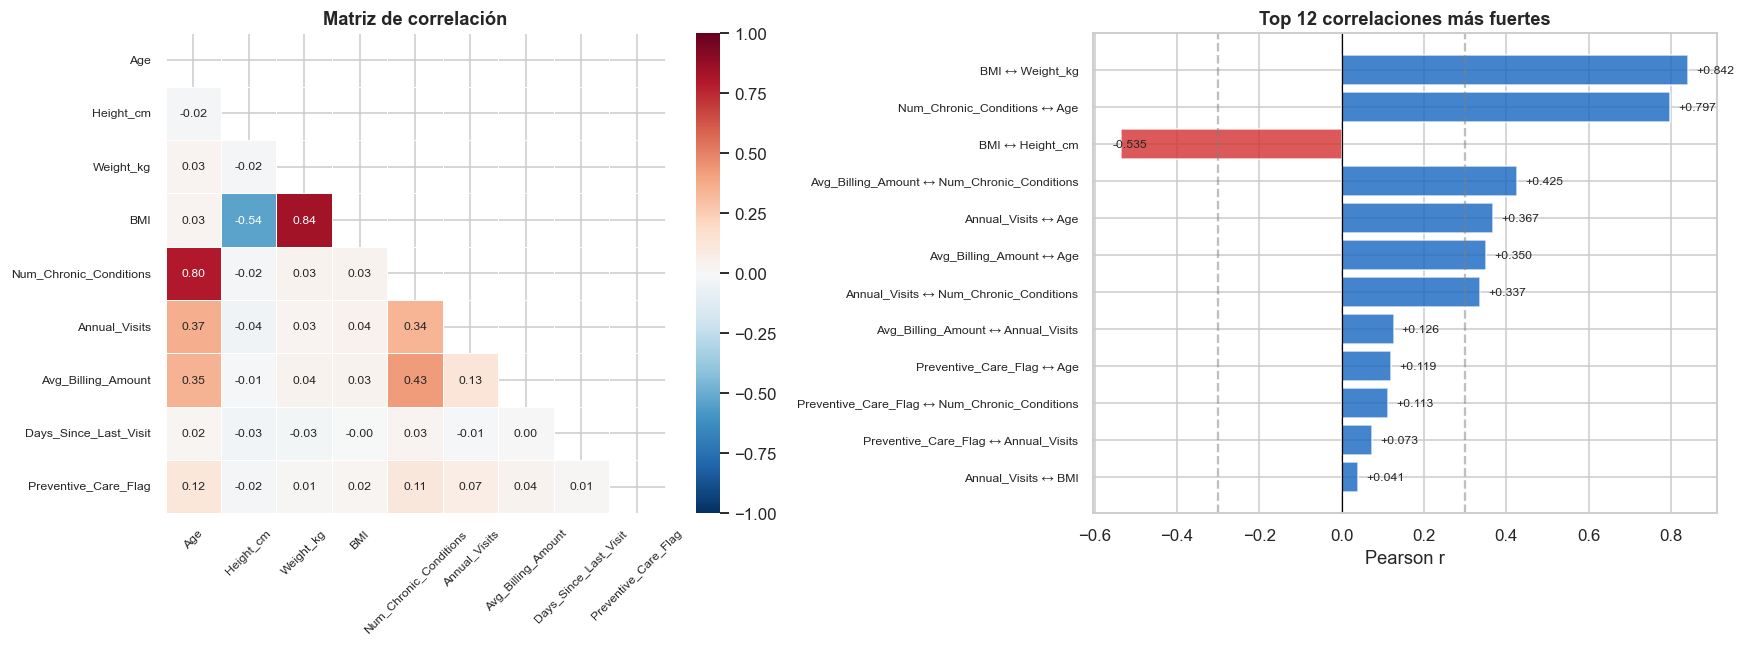

⚠️  VARIABLES COLINEALES (|r| > 0.5):
  BMI                       ↔ Weight_kg                  r = +0.842  → Considerar eliminar una en modelado
  Num_Chronic_Conditions    ↔ Age                        r = +0.797  → Considerar eliminar una en modelado
  BMI                       ↔ Height_cm                  r = -0.535  → Considerar eliminar una en modelado


In [16]:
# --- Heatmap + top correlaciones ---
num_df = df.select_dtypes(include='number').drop(columns=['PatientID'], errors='ignore')
corr = num_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', ax=axes[0], linewidths=0.5,
            annot_kws={'size': 8})
axes[0].set_title('Matriz de correlación', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45, labelsize=8)
axes[0].tick_params(axis='y', labelsize=8)

# Top correlaciones
corr_pairs = (corr.where(np.tril(np.ones(corr.shape), k=-1).astype(bool))
              .stack().reset_index())
corr_pairs.columns = ['Var1', 'Var2', 'r']
corr_pairs['abs_r'] = corr_pairs['r'].abs()
top12 = corr_pairs.sort_values('abs_r', ascending=True).tail(12)

colors_bar = ['#d32f2f' if r < 0 else '#1565c0' for r in top12['r']]
axes[1].barh([f"{row.Var1} ↔ {row.Var2}" for _, row in top12.iterrows()],
             top12['r'], color=colors_bar, alpha=0.8)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].axvline(0.3, color='gray', linestyle='--', alpha=0.5)
axes[1].axvline(-0.3, color='gray', linestyle='--', alpha=0.5)
for _, row in top12.iterrows():
    x_pos = row['r'] + (0.02 if row['r'] > 0 else -0.02)
    axes[1].text(x_pos, list(top12.index).index(list(top12[top12['r']==row['r']].index)[0]),
                 f'{row["r"]:+.3f}', va='center', fontsize=8)
axes[1].set_title('Top 12 correlaciones más fuertes', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Pearson r')
axes[1].tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.show()

print('⚠️  VARIABLES COLINEALES (|r| > 0.5):')
high_corr = corr_pairs[corr_pairs['abs_r'] > 0.5].sort_values('abs_r', ascending=False)
for _, row in high_corr.iterrows():
    print(f'  {row.Var1:25s} ↔ {row.Var2:25s}  r = {row.r:+.3f}  → Considerar eliminar una en modelado')

## 8. Feature Engineering — preparación para Fases 1 y 2

Variables derivadas clave para clustering, regresión y clasificación.

Pacientes inactivos (>180 días): 1013 (50.6%)


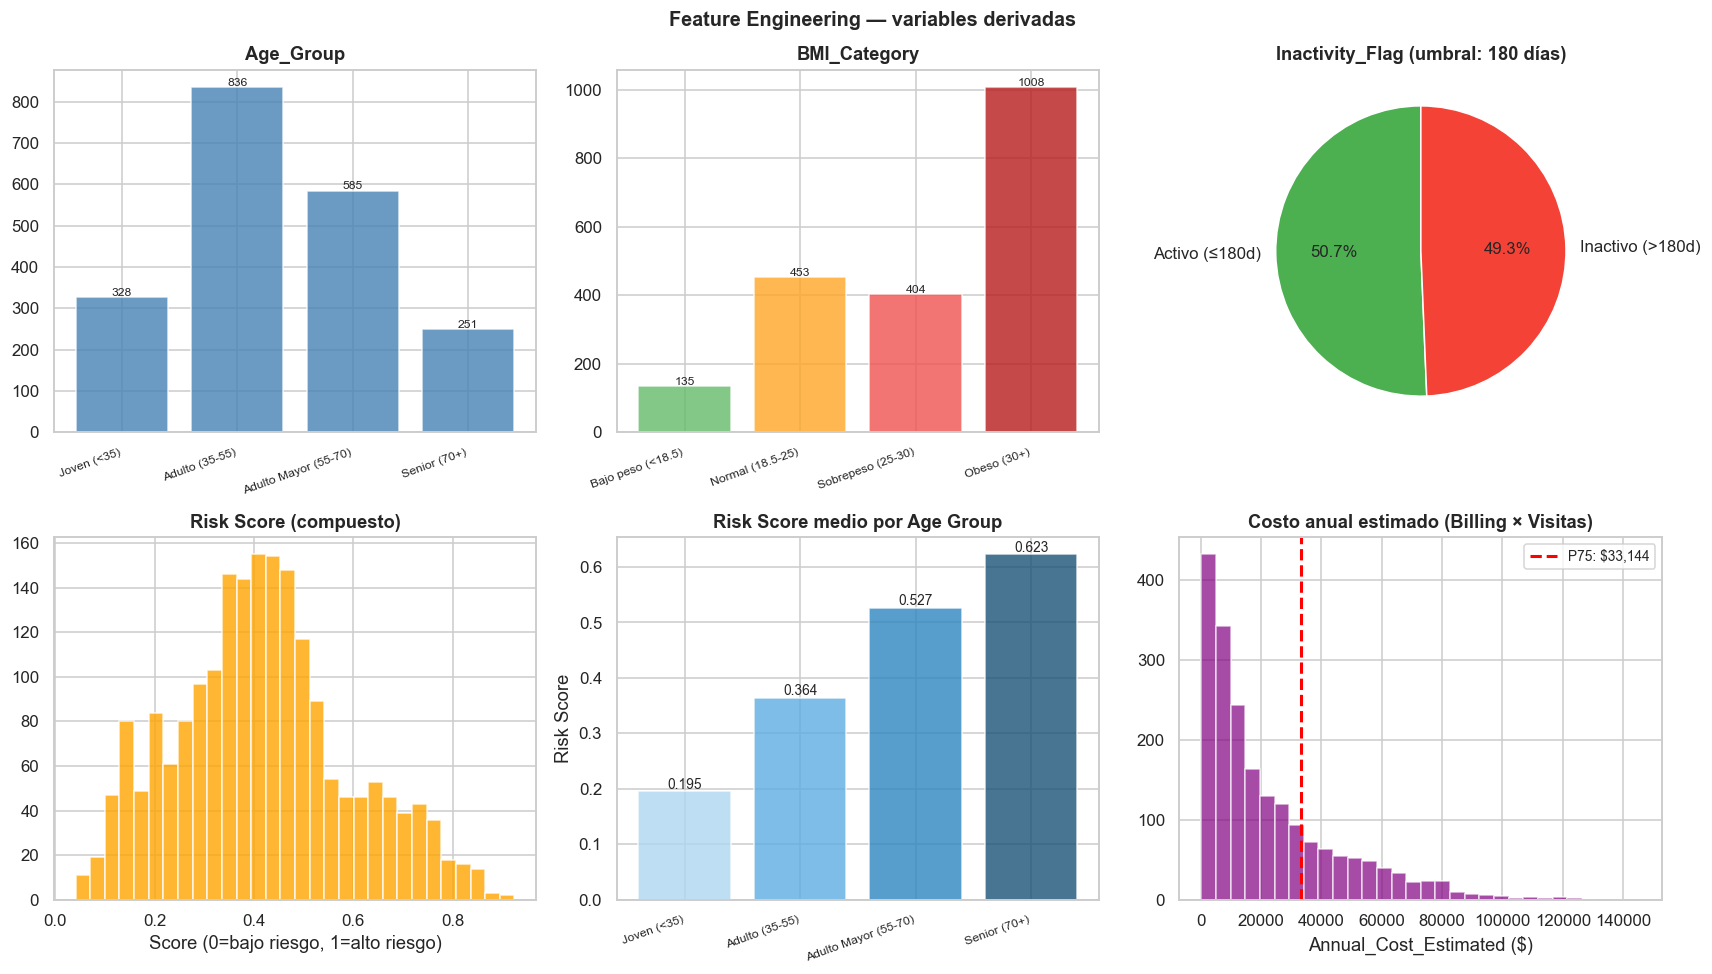


=== RESUMEN DE VARIABLES DERIVADAS ===
  Age_Group: {'Adulto (35-55)': np.int64(836), 'Adulto Mayor (55-70)': np.int64(585), 'Joven (<35)': np.int64(328), 'Senior (70+)': np.int64(251)}
  BMI_Category: {'Obeso (30+)': np.int64(1008), 'Normal (18.5-25)': np.int64(453), 'Sobrepeso (25-30)': np.int64(404), 'Bajo peso (<18.5)': np.int64(135)}
  Inactivity_Flag: media=0.506 | min=0.00 | max=1.00
  Risk_Score: media=0.417 | min=0.04 | max=0.92
  Annual_Cost_Estimated: media=22948.386 | min=236.00 | max=145680.00
  High_Value_Patient: media=0.250 | min=0.00 | max=1.00


In [17]:
df_eng = df.copy()

# --- 1. Grupos de edad ---
bins_age = [0, 35, 55, 70, 100]
labels_age = ['Joven (<35)', 'Adulto (35-55)', 'Adulto Mayor (55-70)', 'Senior (70+)']
df_eng['Age_Group'] = pd.cut(df_eng['Age'], bins=bins_age, labels=labels_age, right=False)

# --- 2. Categoría de BMI (OMS) ---
bins_bmi = [0, 18.5, 25, 30, 100]
labels_bmi = ['Bajo peso (<18.5)', 'Normal (18.5-25)', 'Sobrepeso (25-30)', 'Obeso (30+)']
df_eng['BMI_Category'] = pd.cut(df_eng['BMI'], bins=bins_bmi, labels=labels_bmi, right=False)

# --- 3. Flag de inactividad ---
umbral_inactividad = 180
df_eng['Inactivity_Flag'] = (df_eng['Days_Since_Last_Visit'] > umbral_inactividad).astype(int)
print(f'Pacientes inactivos (>180 días): {df_eng["Inactivity_Flag"].sum()} '
      f'({df_eng["Inactivity_Flag"].mean():.1%})')

# --- 4. Risk Score compuesto ---
# Componentes normalizados: edad, BMI, cronicidad, días inactivo
scaler = MinMaxScaler()
risk_components = ['Age', 'BMI', 'Num_Chronic_Conditions', 'Days_Since_Last_Visit']
risk_scaled = scaler.fit_transform(df_eng[risk_components])
weights = np.array([0.2, 0.2, 0.4, 0.2])  # cronicidad pesa más
df_eng['Risk_Score'] = (risk_scaled * weights).sum(axis=1)

# --- 5. Costo anual estimado ---
df_eng['Annual_Cost_Estimated'] = df_eng['Avg_Billing_Amount'] * df_eng['Annual_Visits']

# --- 6. Paciente de alto valor (por costo anual) ---
umbral_alto_valor = df_eng['Annual_Cost_Estimated'].quantile(0.75)
df_eng['High_Value_Patient'] = (df_eng['Annual_Cost_Estimated'] >= umbral_alto_valor).astype(int)

# --- Visualizar distribuciones de las nuevas variables ---
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Age_Group
vc_age = df_eng['Age_Group'].value_counts().sort_index()
axes[0,0].bar(range(len(vc_age)), vc_age.values, color='steelblue', alpha=0.8)
axes[0,0].set_xticks(range(len(vc_age)))
axes[0,0].set_xticklabels(vc_age.index, rotation=20, ha='right', fontsize=8)
axes[0,0].set_title('Age_Group', fontweight='bold')
for i, v in enumerate(vc_age.values):
    axes[0,0].text(i, v + 3, str(v), ha='center', fontsize=8)

# BMI_Category
vc_bmi = df_eng['BMI_Category'].value_counts().sort_index()
axes[0,1].bar(range(len(vc_bmi)), vc_bmi.values,
              color=['#66BB6A', '#FFA726', '#EF5350', '#B71C1C'], alpha=0.8)
axes[0,1].set_xticks(range(len(vc_bmi)))
axes[0,1].set_xticklabels(vc_bmi.index, rotation=20, ha='right', fontsize=8)
axes[0,1].set_title('BMI_Category', fontweight='bold')
for i, v in enumerate(vc_bmi.values):
    axes[0,1].text(i, v + 3, str(v), ha='center', fontsize=8)

# Inactivity_Flag
vc_inact = df_eng['Inactivity_Flag'].value_counts()
axes[0,2].pie(vc_inact.values, labels=['Activo (≤180d)', 'Inactivo (>180d)'],
              colors=['#4CAF50', '#F44336'], autopct='%1.1f%%', startangle=90)
axes[0,2].set_title(f'Inactivity_Flag (umbral: {umbral_inactividad} días)', fontweight='bold')

# Risk Score
axes[1,0].hist(df_eng['Risk_Score'], bins=30, color='orange', alpha=0.8, edgecolor='white')
axes[1,0].set_title('Risk Score (compuesto)', fontweight='bold')
axes[1,0].set_xlabel('Score (0=bajo riesgo, 1=alto riesgo)')

# Risk Score por Age Group
rs_by_age = df_eng.groupby('Age_Group')['Risk_Score'].mean()
axes[1,1].bar(range(len(rs_by_age)), rs_by_age.values,
              color=['#AED6F1', '#5DADE2', '#2E86C1', '#1A5276'], alpha=0.8)
axes[1,1].set_xticks(range(len(rs_by_age)))
axes[1,1].set_xticklabels(rs_by_age.index, rotation=20, ha='right', fontsize=8)
axes[1,1].set_title('Risk Score medio por Age Group', fontweight='bold')
axes[1,1].set_ylabel('Risk Score')
for i, v in enumerate(rs_by_age.values):
    axes[1,1].text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=9)

# Annual Cost Estimated
axes[1,2].hist(df_eng['Annual_Cost_Estimated'], bins=30,
               color='purple', alpha=0.7, edgecolor='white')
axes[1,2].axvline(umbral_alto_valor, color='red', linestyle='--', linewidth=2,
                  label=f'P75: ${umbral_alto_valor:,.0f}')
axes[1,2].set_title('Costo anual estimado (Billing × Visitas)', fontweight='bold')
axes[1,2].set_xlabel('Annual_Cost_Estimated ($)')
axes[1,2].legend(fontsize=9)

plt.suptitle('Feature Engineering — variables derivadas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n=== RESUMEN DE VARIABLES DERIVADAS ===')
new_vars = ['Age_Group', 'BMI_Category', 'Inactivity_Flag', 'Risk_Score',
            'Annual_Cost_Estimated', 'High_Value_Patient']
for v in new_vars:
    if df_eng[v].dtype.name in ['object', 'category']:
        print(f'  {v}: {dict(df_eng[v].value_counts())}')
    else:
        print(f'  {v}: media={df_eng[v].mean():.3f} | min={df_eng[v].min():.2f} | max={df_eng[v].max():.2f}')

## 9. Conclusiones del EDA v2

### Hallazgos clave confirmados

| Hipótesis | Resultado | Evidencia |
|-----------|-----------|----------|
| H1: Privado = mayor costo |  SORPRESA | Medicare > Privado en facturación |
| H2: Cronicidad → mayor costo |  CONFIRMADA | Gradiente $2,598 → $6,124 (0→3 condiciones) |
| H3: Prevención reduce costos |  REFUTADA | Preventivos gastan más (sesgo de selección) |
| H7: Desigualdad por género |  LEVE | Mujeres: BMI mayor, facturación levemente superior |
| H8: Edad = driver principal |  CONFIRMADA | r=0.80 con cronicidad, mediadora clave |

### Estructura de datos para modelado

| Variable target | Predictores recomendados | R² esperado |
|----------------|--------------------------|-------------|
| `Avg_Billing_Amount` | Age, Num_Chronic, Insurance, Annual_Visits | ~0.35–0.50 |
| Clustering | Age, BMI, Num_Chronic, Annual_Visits, Days_Since, Billing | 3–4 clusters |
| `Inactivity_Flag` | Age, Preventive_Care, Num_Chronic, Days_Since | TBD |

### Alertas para el modelado
-  **Colinealidad:** `Weight_kg` ↔ `BMI` (r=0.84) — usar solo BMI en modelos
-  **Colinealidad:** `Height_cm` ↔ `BMI` (r=-0.54) — idem
-  **Sesgo de selección:** `Preventive_Care_Flag` no debe usarse como indicador de costo menor
-  **City** (50.6% Unknown): excluir de análisis geográfico, usar `State`

In [46]:
# Guardar dataset con features para usar en fases siguientes
df_eng.to_csv('3_patient_segmentation_engineered.csv', index=False)
print(f'Dataset con features guardado: {df_eng.shape[0]} filas × {df_eng.shape[1]} columnas')
print(f'Columnas nuevas: {[c for c in df_eng.columns if c not in df.columns]}')

Dataset con features guardado: 2000 filas × 22 columnas
Columnas nuevas: ['Age_Group', 'BMI_Category', 'Inactivity_Flag', 'Risk_Score', 'Annual_Cost_Estimated', 'High_Value_Patient']
